# Binary Classification: Breast Cancer Set from Wisconsin University

## 0. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

## 1. Frame the Problem

### Questions to Ask

1. What is the **business __or__ research objective** in building this machine learning model?
   - **Goal:** To detect whether the patient has a high probability of having breast cancer (a benign(**0**) or malignant tumor(**1**)) given a set amount of features.
2. How does the research facility (medical org., company, etc.) expect to use and benefit from this model?
    - To help assist with a more accurate diagnosis of breast cancer and help cure it before symptoms worsen, leading to the saving of lives.
3. Performance Metrics Used
   - ROC-AUC and F1-Score
   - The ROC-AUC is chosen along with the F1-SCore becuase False Negatives as costly (missing cancer, when it's present) and ROC-AUC evaluates ranking quality independent of threshold
4. Assumptions
    - Features are numeric and meaningful
    - Observations are independent of one another
    - Measurement noise exists but is within tolerable ranges



## 2. Get the Data

In [2]:
data = load_breast_cancer()

In [3]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target") #label is 1D data, so we use Series instead of DataFrame,
# you still can use y = pd.DataFrame(data.target, columns=["target"])

### Quick Look at Data

In [4]:
display(X)
display(y.value_counts())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


target
1    357
0    212
Name: count, dtype: int64

In [5]:
X.info()
y.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

### Create the Train-Test Split

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    stratify=y,
    random_state=42
)

## 3. Exploratory Data Analysis (EDA)

### Visualize the Feature Distribution : It shows the distribution of every feature using histograms.
Why we want to see the Shape of the Data?

You can check:

Is it normal (bell-shaped)?

Is it skewed left or right? ex. long tail extending to the right-> right skew

Is it uniform?

Does it have multiple peaks?

Example:

Some features in the plots below are right-skewed.

Some look roughly normal.

This matters because some models assume normality.

#### you can also detect Outliers-> If a histogram has a long tail:

→ That feature might contain extreme values
→ You might need scaling or transformation

#### Understand Data Before Modeling

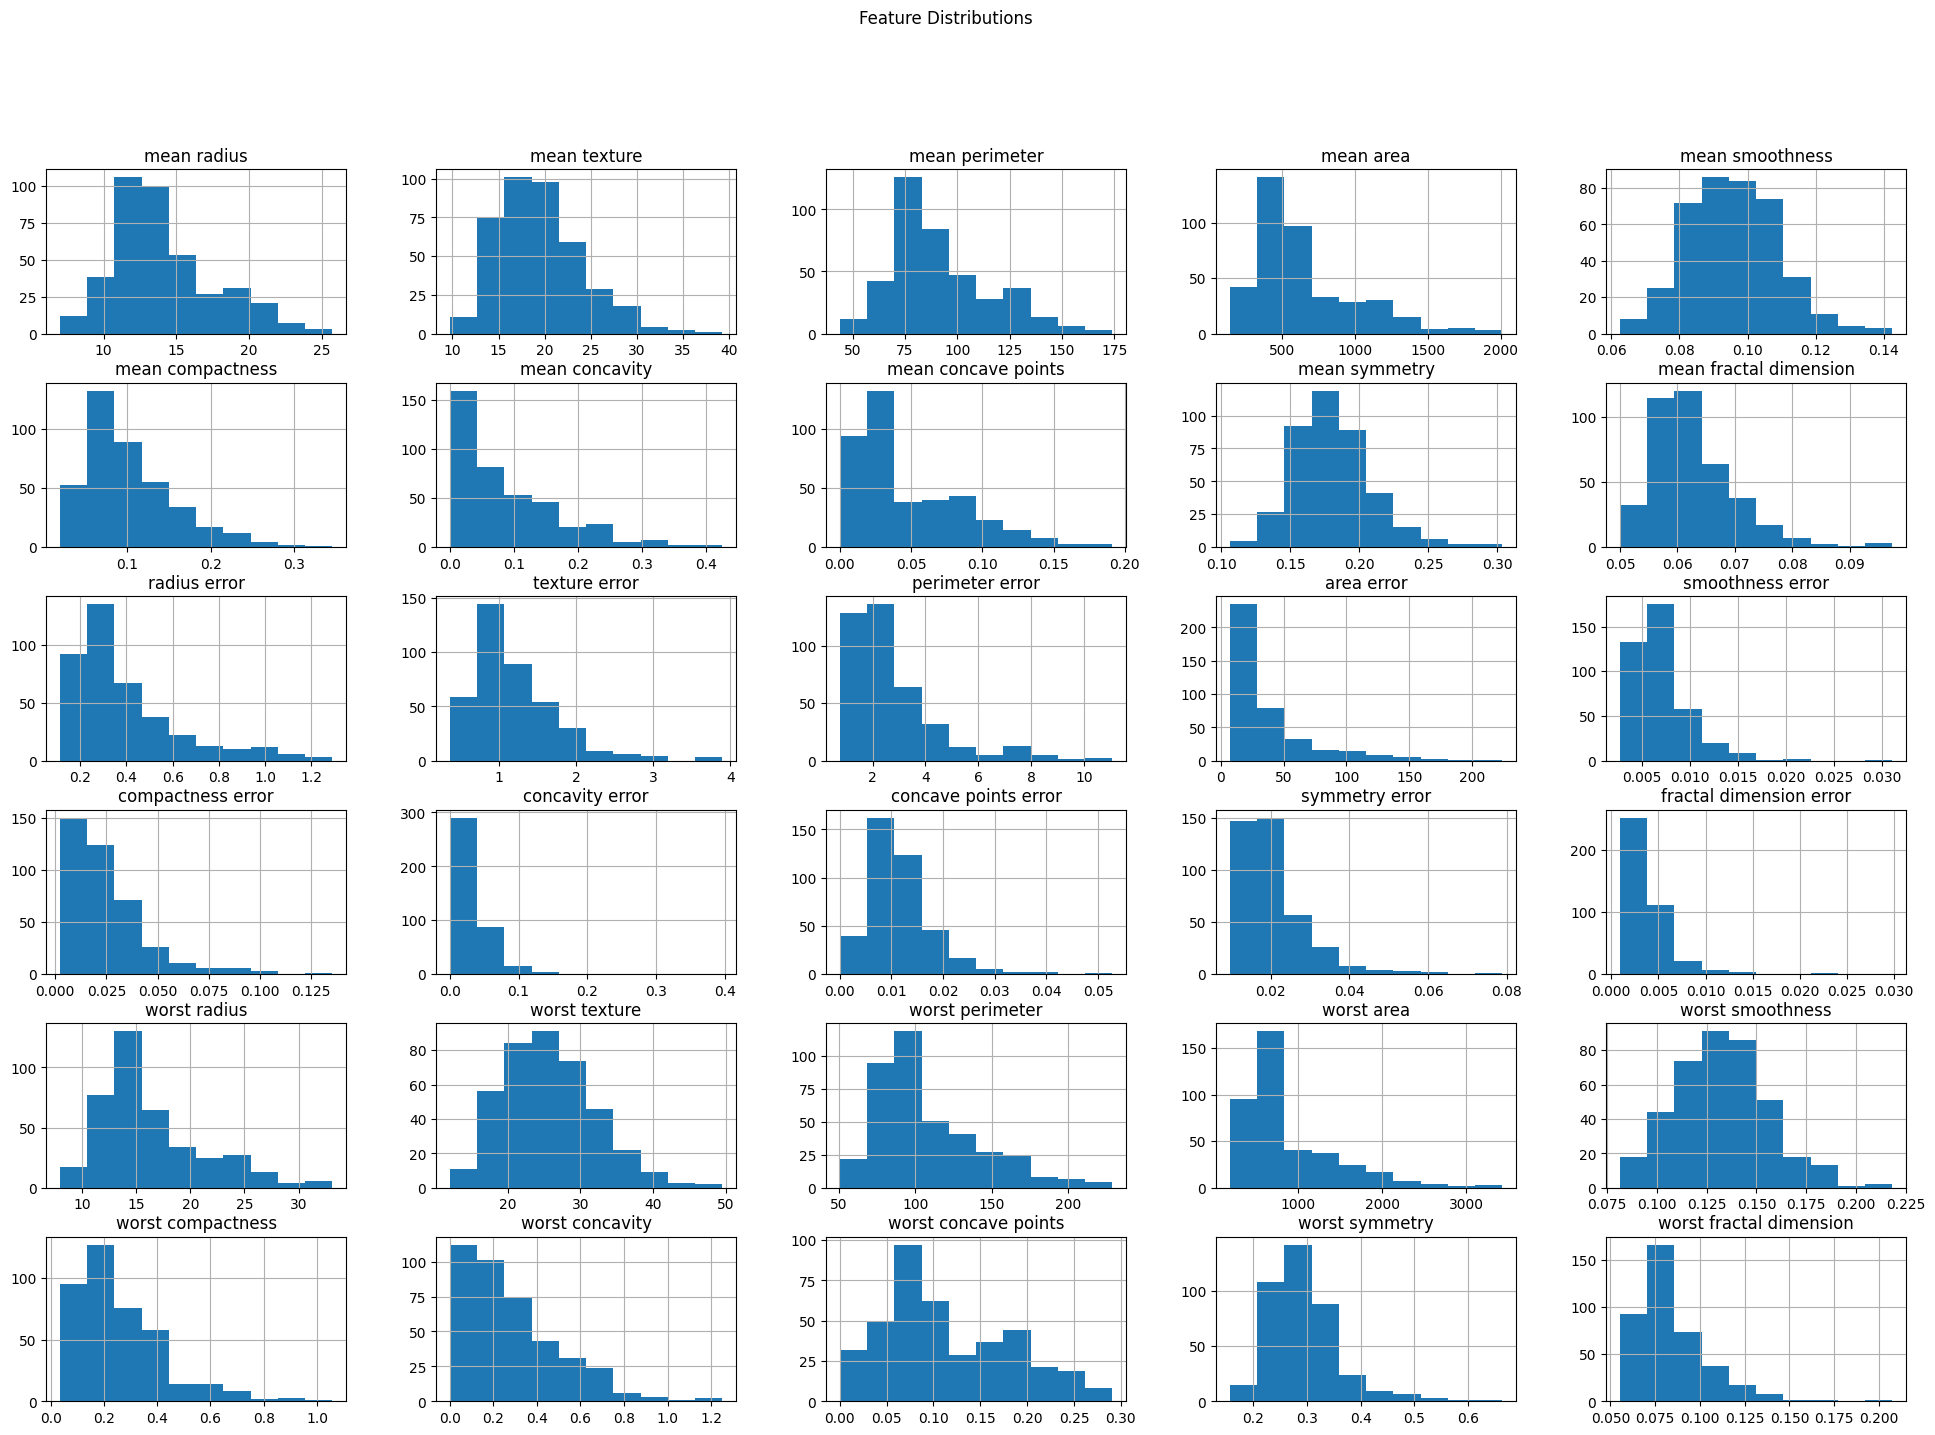

In [7]:
X_train.hist(figsize=(24,16))
plt.suptitle("Feature Distributions")
plt.show()

### Correlation HeatMap
##### It shows how strongly features are related to each other.


If two features are highly correlated (like 0.95):

That means they carry almost the same information.

Example this dataset:

mean radius & mean perimeter & mean area

These are usually highly correlated.

Using all of them can:

Make linear models unstable / Increase variance/ Reduce interpretability

We can drop one of them or cluster them

<Axes: >

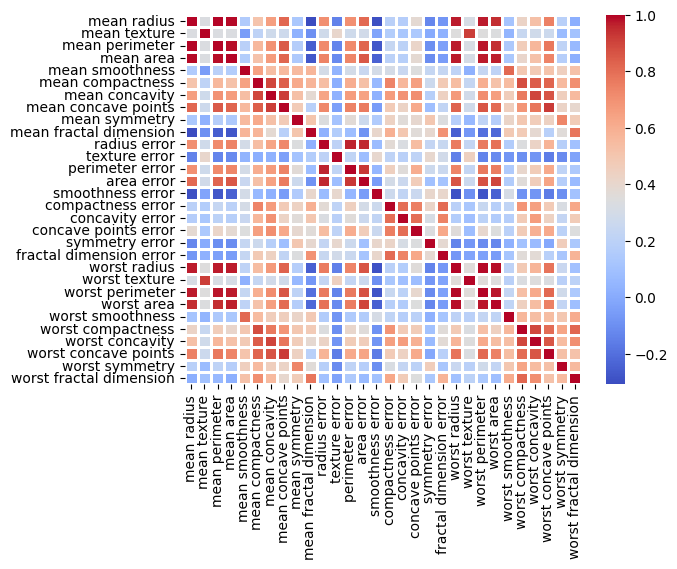

In [8]:
sns.heatmap(X_train.corr(),cmap="coolwarm", linewidths=1, xticklabels=True, yticklabels=True)

### Attribute Combinations
radius_worst_to_mean=mean_radius/ worst_radius​

it shows:How much worse the worst-case radius is compared to the average radius.

ratio is more informaive

In [9]:
X_train["radius_worst_to_mean"] = X_train["worst radius"] / X_train["mean radius"]
X_test["radius_worst_to_mean"] = X_test["worst radius"] / X_test["mean radius"]

## 4. Prepare the Data and Model for ML

### Data Cleaning

In [10]:
# drop rows where all values are NaN, inplace means we modify the original DataFrame instead of creating a new one
X_train.dropna(axis=0, how="all", inplace=True)
X_train.dropna(axis=1, how="all", inplace=True)
X_test.dropna(axis=0, how="all", inplace=True)
X_test.dropna(axis=1, how="all", inplace=True)

y_train.dropna(axis=0, how="all", inplace=True)
y_test.dropna(axis=0, how="all", inplace=True)

In [11]:
print(f" X_train: {len(X_train)}")
print(f" y_train: {len(y_train)}")
print(f" X_test: {len(X_test)}")
print(f" y_test: {len(y_test)}")

 X_train: 398
 y_train: 398
 X_test: 171
 y_test: 171


### Build the Data Pipeline

In [12]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

features = X_train.select_dtypes(include=["float64"]).columns
#It selects only columns with data type float64

pipeline = Pipeline([ # define a pipeline object for numerical features,
    ("scaler", StandardScaler())
])

preprocessing = ColumnTransformer([ # For all numeric feature columns, apply scaling.
    ("num",pipeline, features)
])

# note: for complicated data, with both numberitic and categorical features (ex. one-hard encoding), we need to use ColumnTransformer to process differently
# Ex. ColumnTransformer([
#    ("num", StandardScaler(), numeric_columns),
#    ("cat", OneHotEncoder(), categorical_columns)
# ]) ,

In [13]:
display(features)
len(features) # extra feature we created, so 30 original features + 1 new feature = 31 features in total
#the extra feature is 'radius_worst_to_mean'

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'radius_worst_to_mean'],
      dtype='str')

31

### Create a Baseline Model

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

baseline = Pipeline([
    ("prep", preprocessing),
    ("model", DummyClassifier(strategy="stratified")) # randomly generates predictions, baseline
])

#Note: for simple piplines(only numeric features), we can define model this way:
#model = Pipeline([
#    ("scaler", StandardScaler()),
#     ("model", DummyClassifier(strategy="stratified"))
# ]))



# Stratified K-Fold Cross Validation, split=5

#Fold 1 → 80% train, 20% validation
#Fold 2 → 80% train, 20% validation
#Fold 3 → 80% train, 20% validation
#Fold 4 → 80% train, 20% validation
#Fold 5 → 80% train, 20% validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=skf, # cv = cross-validation strategy, use the StratifiedKFold object we created
    scoring="roc_auc",
    n_jobs=-1, #Use all available CPU cores
    verbose=1
)
baseline_scores.mean() #ROC-AUC ~= 0.472

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   19.5s finished


np.float64(0.5017471264367817)

## 5. Select and Train a Model

In [15]:
from sklearn.linear_model import LogisticRegression

breast_cancer_classifier = make_pipeline(preprocessing, LogisticRegression(class_weight="balanced", random_state=42)) # preprocessing was defined before
# using class_weight="balanced" to handle the class imbalance in the dataset, it will assign higher weights to the minority class (malignant)

#make_pipeline is just another way to make pipeline; it is the same as:
# breast_cancer_classifier = Pipeline([
#    ("preprocessing", preprocessing),
#    ("logistic_regressor", LogisticRegression(class_weight="balanced", random_state=42))
#     ])


breast_cancer_classifier.fit(X_train, y_train) # the last line of the notebook, so we can see the output of this line, which is the fitted model.

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Re-evaluate with K-Fold Cross Validation (Stratified)

In [16]:
bcc = cross_val_score(
    breast_cancer_classifier,
    X_train,
    y_train,
    scoring="roc_auc",
    cv=skf
)

bcc.mean()

np.float64(0.9934252873563219)

## 6. Fine Tune the Model

In [17]:
full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("logistic_regressor", LogisticRegression(class_weight="balanced", random_state=42))
     ])

In [18]:
#Let's get some default paramters for logistic regression, and see if we can improve the model performance by tuning these hyperparameters.
LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [19]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    # Logistics Regressor hyperparameters
    # for details of these hyperparameters, please refer to the documentation: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
    "logistic_regressor__l1_ratio": [0,0.5,1], # controls mix of L1 and L2 regularization, only used when penalty is "elasticnet"
    "logistic_regressor__fit_intercept": [True, False],
    "logistic_regressor__intercept_scaling": [0.5, 1, 2],
    "logistic_regressor__solver": ["saga"],
    "logistic_regressor__C": [0.01, 0.1, 1, 10, 100],
    "logistic_regressor__max_iter": [100,200,300],
}


# Initialize the GridSearchCV object
grid_search = GridSearchCV(full_pipeline, param_grid, cv=skf, scoring='roc_auc', n_jobs=-1, verbose=3)
#GridSearchCV is a powerful tool for hyperparameter tuning,
# For every combination of those hyperparameters:
#It run 5-foled cross validation, and evaluate the model performance using ROC-AUC

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score achieved during the grid search
print("\n\nBest parameters:", grid_search.best_params_)
print("\nBest cross-validation score:", grid_search.best_score_)

Fitting 5 folds for each of 270 candidates, totalling 1350 fits


Best parameters: {'logistic_regressor__C': 0.1, 'logistic_regressor__fit_intercept': False, 'logistic_regressor__intercept_scaling': 0.5, 'logistic_regressor__l1_ratio': 1, 'logistic_regressor__max_iter': 100, 'logistic_regressor__solver': 'saga'}

Best cross-validation score: 0.9951586206896552


c:\Users\Troy\Downloads\cpsc483_spring_2026\lab-venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 7. Create, Evaluate, and Save the Finalized Model

In [20]:
#Now the best paramter is
#C = 0.1
#fit_intercept = False
#intercept_scaling = 0.5
#l1_ratio = 1
#max_iter = 100
#solver = 'saga

bcc = make_pipeline(preprocessing, LogisticRegression(class_weight="balanced", fit_intercept=True,intercept_scaling=0.5,l1_ratio=1,max_iter=100,solver="liblinear"))
bcc = make_pipeline(
    preprocessing,
    LogisticRegression(
        C=0.1,
        class_weight="balanced",
        solver="saga",
        l1_ratio=1,          # 1 means “L1-style”
        fit_intercept=False,
        intercept_scaling=0.5,
        max_iter=100,
        random_state=42
    )
)

bcc.fit(X_train,y_train)

c:\Users\Troy\Downloads\cpsc483_spring_2026\lab-venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [21]:
bcc[1].coef_
# 31 coefficients(weights), one for each feature, including the new feature we created, 'radius_worst_to_mean'

array([[-0.16508902, -0.05494204, -0.17297898, -0.16305843,  0.        ,
         0.        ,  0.        , -0.72426029,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        -0.60372586, -0.41649237, -0.40102106, -0.24122411, -0.01527973,
         0.        ,  0.        , -0.86591659, -0.08103817,  0.        ,
        -0.73958976]])

### Evaluate on the Test Set

In [22]:
# Hard predictions
y_test_pred = bcc.predict(X_test)

# Probabilities (needed for ranking metrics)
y_test_proba = bcc.predict_proba(X_test)

In [23]:
print(y_test_pred)

[0 1 1 0 0 0 1 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 0 0 0 0
 1 1 1 1 0 1 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1
 1 0 1 1 0 0 0 1 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1 1 1 0 0 0 0 0 1
 0 1 1 1 0 1 0 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 1]


In [24]:
print(y_test_proba) #sklearn predict [ P(class 0), P(class 1) ] where P(class 0 ) = 1- P(class 1)
#if we want to play with threshold ,we can do something like this:
#y_test_pred_threshold = (y_test_proba[:,1] >= 0.3).astype(int) # if P(class 1) >= 0.3, predict class 1, otherwise predict class 0

[[8.58051086e-01 1.41948914e-01]
 [8.38875532e-02 9.16112447e-01]
 [6.54955391e-02 9.34504461e-01]
 [9.86394836e-01 1.36051645e-02]
 [5.42488208e-01 4.57511792e-01]
 [9.46189438e-01 5.38105624e-02]
 [3.22006221e-03 9.96779938e-01]
 [9.65008008e-01 3.49919919e-02]
 [8.52782969e-02 9.14721703e-01]
 [9.99552780e-01 4.47220198e-04]
 [1.26414437e-02 9.87358556e-01]
 [1.02160997e-01 8.97839003e-01]
 [9.75033386e-01 2.49666141e-02]
 [6.17558856e-01 3.82441144e-01]
 [3.44734916e-02 9.65526508e-01]
 [6.13405837e-01 3.86594163e-01]
 [9.80210592e-01 1.97894080e-02]
 [4.46841185e-01 5.53158815e-01]
 [4.17334211e-02 9.58266579e-01]
 [2.57748238e-01 7.42251762e-01]
 [8.40992631e-02 9.15900737e-01]
 [2.62342653e-01 7.37657347e-01]
 [1.61928592e-01 8.38071408e-01]
 [9.96385567e-01 3.61443287e-03]
 [9.96099720e-01 3.90027968e-03]
 [3.78406769e-01 6.21593231e-01]
 [4.44995140e-02 9.55500486e-01]
 [2.02472801e-01 7.97527199e-01]
 [9.64577974e-01 3.54220257e-02]
 [9.79372774e-01 2.06272264e-02]
 [3.588997

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
class_names = [str(cls) for cls in sorted(y_train.unique())]
conf_matrix = confusion_matrix(y_test, y_test_pred)
class_report = classification_report(y_test, y_test_pred, target_names=class_names)
print('Confusion Matrix:\n', conf_matrix)
print('Classification Report:\n', class_report)

Confusion Matrix:
 [[ 62   2]
 [  3 104]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        64
           1       0.98      0.97      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



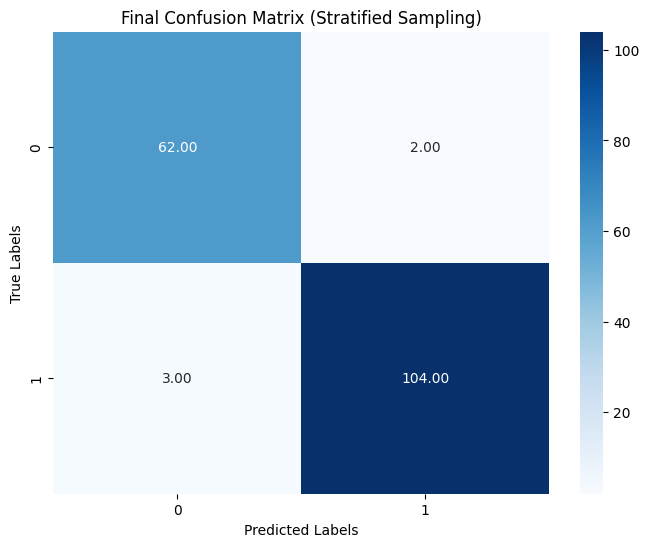

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Final Confusion Matrix (Stratified Sampling)')
plt.show()

##### Note: the Confusion Matrix here is transposed of the matrix show in the lecture side, here is the order of data in this confusion matrix
![ ->](attachment:image.png)  is different from the slide as shown below

![image-2.png](attachment:image-2.png)

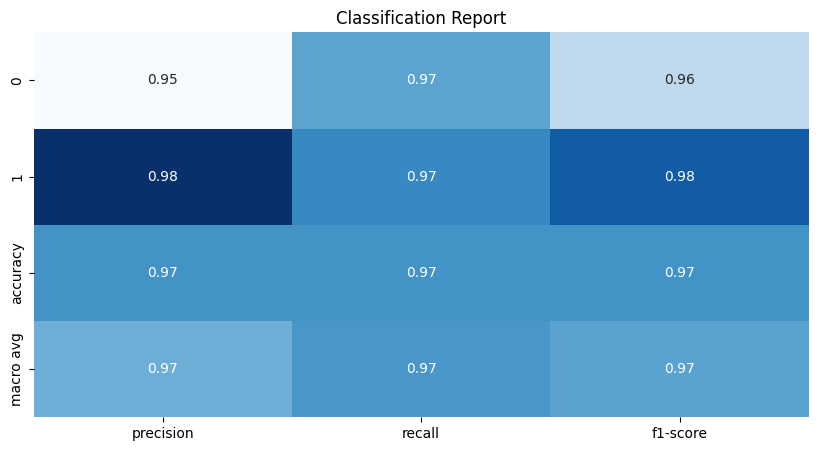

In [ ]:
class_report = classification_report(y_test, y_test_pred, target_names=class_names, output_dict=True)
df_final_report = pd.DataFrame(class_report).transpose()

plt.figure(figsize=(10, 5))
sns.heatmap(df_final_report.iloc[:-1, :].drop(columns=['support']), annot=True, cmap='Blues', cbar=False)
plt.title('Classification Report')
plt.legend()
plt.show()

##### Note: Class 0: Benign, Class 1: Cancer

#### Class 0 TP = Class 1 TN

#### Class 0 FP = Class 1 FN

#### Class 0 FN = Class 1 FP

#### Class 0 TN = Class 1 TP

#### so some of the values in heatmap are the same
### accuracy is 0.97, only one value


Closest threshold: 0.4979919150662221
FPR at 0.5: 0.03125
TPR at 0.5: 0.9813084112149533


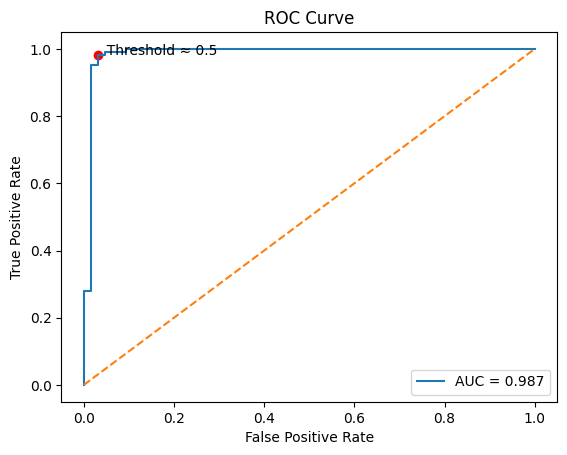

In [28]:
#Draw ROC curve and calculate AUC
#step 1: Get probability of positive class P(class 1)
y_proba = bcc.predict_proba(X_test)[:, 1]
#step 2: calculate FPR, TPR, and thresholds
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# plot the point for threshold = 0.5
idx = np.argmin(np.abs(thresholds - 0.5))

print("Closest threshold:", thresholds[idx])
print("FPR at 0.5:", fpr[idx])
print("TPR at 0.5:", tpr[idx])


# plot ROC curve
# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.scatter(fpr[idx], tpr[idx], color="red")
plt.text(fpr[idx], tpr[idx], "  Threshold ≈ 0.5")

plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 7. Naive Bayes (GaussianNB) – Another Binary Classifier

Naive Bayes is a **probabilistic** classifier based on Bayes’ theorem with a strong (naive) assumption that features are **conditionally independent** given the class.

For **continuous numeric features**, the most common choice is **Gaussian Naive Bayes** (`GaussianNB`), which assumes each feature follows a normal distribution within each class:

![image.png](attachment:image.png)

- It is **fast** to train and predict.
- Works surprisingly well as a **baseline** on many problems.
- The independence assumption is often false, but performance can still be good.
- This is a general form of the Baye's theorey(the one we discussed in the classroom), if you are interested in how to derive the equation for Naive Bayes, here is a good video : https://www.youtube.com/watch?v=lJGHZO0rqs0  

### Important notes
- `GaussianNB` can work without scaling, but scaling can help numerical stability and make features comparable.

![image-2.png](attachment:image-2.png)

- Use `predict_proba()` for ROC/AUC (same idea as Logistic Regression).


In [30]:
# Naive Bayes (GaussianNB)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

# If you already have 'preprocessing' defined (e.g., scaler for numeric columns),
# you can reuse it here. This keeps preprocessing consistent across models.
nb_model = make_pipeline(preprocessing, GaussianNB())

# Train
nb_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('gaussiannb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contai

In [ ]:
# Evaluate on the test set
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Hard predictions
y_nb_pred = nb_model.predict(X_test)

# Probabilities for ROC/AUC (use probability of class 1)
y_nb_proba = nb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_nb_pred))
print("Naive Bayes ROC-AUC:", roc_auc_score(y_test, y_nb_proba))


              precision    recall  f1-score   support

           0       0.97      0.89      0.93        64
           1       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171

Naive Bayes ROC-AUC: 0.9915303738317757


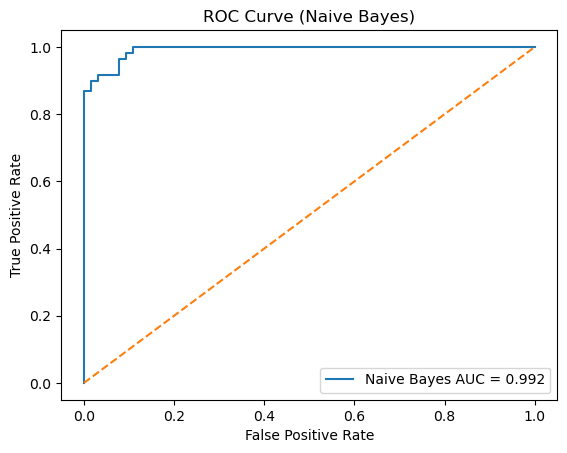

In [ ]:
# Plot ROC curve for Naive Bayes
fpr_nb, tpr_nb, thr_nb = roc_curve(y_test, y_nb_proba)
auc_nb = roc_auc_score(y_test, y_nb_proba)

plt.figure()
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes AUC = {auc_nb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Naive Bayes)")
plt.legend()
plt.show()


In [31]:
# (Optional) Cross-validation ROC-AUC for Naive Bayes
from sklearn.model_selection import cross_val_score
nb_clf = make_pipeline(preprocessing, GaussianNB())

nb_scores = cross_val_score(
    nb_clf,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("Naive Bayes CV ROC-AUC scores:", nb_scores)
print("Naive Bayes mean CV ROC-AUC:", nb_scores.mean())


Naive Bayes CV ROC-AUC scores: [0.99466667 0.98933333 0.99266667 0.98758621 0.98482759]
Naive Bayes mean CV ROC-AUC: 0.989816091954023



## 8. Side-by-Side Model Comparison

In this section, we compare the performance of **Logistic Regression** and **Naive Bayes** on the same test dataset.

To ensure a fair evaluation, both models are assessed using identical metrics:

- **Accuracy** – Overall correctness of predictions  
- **Precision (Class 1 – Malignant)** – How reliable positive predictions are  
- **Recall (Class 1 – Malignant)** – How well the model detects cancer cases  
- **F1-Score (Class 1)** – Balance between precision and recall  
- **ROC-AUC** – Overall ability to distinguish between classes  

This side-by-side comparison helps us understand:

- Which model performs better overall  
- Which model is more effective at detecting malignant cases  
- The trade-off between sensitivity (recall) and false positives  

By analyzing these metrics together, we can make a more informed decision about the most appropriate model for this medical classification problem.


In [32]:

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression metrics
lr_pred = bcc.predict(X_test)
lr_proba = bcc.predict_proba(X_test)[:, 1]

# Naive Bayes metrics
nb_pred = nb_model.predict(X_test)
nb_proba = nb_model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame({
    "Metric": ["Accuracy",
               "Precision (Class 1)",
               "Recall (Class 1)",
               "F1 (Class 1)",
               "ROC-AUC"],

    "Logistic Regression": [
        accuracy_score(y_test, lr_pred),
        precision_score(y_test, lr_pred),
        recall_score(y_test, lr_pred),
        f1_score(y_test, lr_pred),
        roc_auc_score(y_test, lr_proba)
    ],

    "Naive Bayes": [
        accuracy_score(y_test, nb_pred),
        precision_score(y_test, nb_pred),
        recall_score(y_test, nb_pred),
        f1_score(y_test, nb_pred),
        roc_auc_score(y_test, nb_proba)
    ]
})

comparison


,Metric,Logistic Regression,Naive Bayes
0,Accuracy,0.970760,0.947368
1,Precision (Class 1),0.981132,0.937500
2,Recall (Class 1),0.971963,0.981308
3,F1 (Class 1),0.976526,0.958904
4,ROC-AUC,0.987296,0.991530
